In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

In [2]:
profit_loss = pd.read_csv(
    "exports/clean_profit_loss.csv"
)

balance_sheet = pd.read_csv(
    "exports/clean_balance_sheet.csv"
)

cash_flow = pd.read_csv(
    "exports/clean_cash_flow.csv"
)

analysis = pd.read_csv(
    "exports/clean_analysis.csv"
)

In [3]:
print(profit_loss.shape)
print(balance_sheet.shape)
print(cash_flow.shape)
print(analysis.shape)

(1276, 18)
(1312, 15)
(1187, 7)
(20, 6)


In [4]:
profit_loss["opm"] = (
    profit_loss["operating_profit"] /
    (profit_loss["sales"] + 1)
) * 100

In [5]:
opm = (
    profit_loss.groupby("company_id")["opm"]
    .mean()
)

In [6]:
balance_sheet["roe"] = (
    balance_sheet["reserves"] /
    (
        balance_sheet["equity_capital"] + 1
    )
) * 100

In [7]:
roe = (
    balance_sheet.groupby("company_id")["roe"]
    .mean()
)


In [12]:
sales_growth = (
    profit_loss.groupby("company_id")["sales"]
    .agg(["first", "last"])
)

In [9]:
sales_growth["avg_growth_3y"] = (
    (
        sales_growth["last"] /
        (sales_growth["first"] + 1)
    ) ** (1/3) - 1
) * 100

In [10]:
balance_sheet["de_ratio"] = (
    balance_sheet["borrowings"] /
    (
        balance_sheet["equity_capital"] +
        balance_sheet["reserves"] + 1
    )
)

In [11]:
de_ratio = (
    balance_sheet.groupby("company_id")["de_ratio"]
    .mean()
)

In [13]:
cash_merged = cash_flow.merge(
    profit_loss[
        [
            "company_id",
            "year",
            "net_profit"
        ]
    ],
    on=["company_id", "year"],
    how="left"
)

In [16]:
cash_merged["cash_conversion"] = (
    cash_merged["operating_activity"] /
    (cash_merged["net_profit"] + 1)
)

In [17]:
cash_conversion = (
    cash_merged.groupby("company_id")["cash_conversion"]
    .mean()
)

In [18]:
dividend = (
    profit_loss.groupby("company_id")["dividend_payout"]
    .mean()
)

In [20]:
sales_growth.columns

Index(['first', 'last'], dtype='object')

In [21]:
sales_growth["avg_growth_3y"] = (
    (
        sales_growth["last"] /
        (sales_growth["first"] + 1)
    ) ** (1/3) - 1
) * 100

In [22]:
sales_growth.head()

,first,last,avg_growth_3y
company_id,,,
ABB,1653,6066,54.213467
ADANIENSOL,0,22099,2706.236101
ADANIENT,46375,102311,30.179624
ADANIGREEN,502,10782,177.786060
ADANIPORTS,3577,28443,99.577551


In [23]:
cluster_data = pd.DataFrame({
    "avg_opm": opm,
    "avg_roe": roe,
    "avg_growth_3y": sales_growth["avg_growth_3y"],
    "avg_debt_to_equity": de_ratio,
    "avg_cash_conversion": cash_conversion,
    "avg_dividend": dividend
})

In [24]:
cluster_data.fillna(0, inplace=True)

In [25]:
cluster_data.head()

,avg_opm,avg_roe,avg_growth_3y,avg_debt_to_equity,avg_cash_conversion,avg_dividend
company_id,,,,,,
ABB,17.873472,9315.734266,54.213467,0.019963,2.822420,49.416667
ADANIENSOL,46.294412,600.414045,2706.236101,3.003669,3.976267,0.000000
ADANIENT,9.180307,20320.850884,30.179624,1.777247,4.059843,7.666667
ADANIGREEN,69.613593,178.985514,177.786060,8.291258,-1.174597,0.000000
ADANIPORTS,60.670344,6375.659199,99.577551,1.275917,1.441998,13.000000


In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(cluster_data)

In [27]:
inertia = []

K = range(2,10)

for k in K:
    
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    model.fit(X_scaled)
    
    inertia.append(model.inertia_)

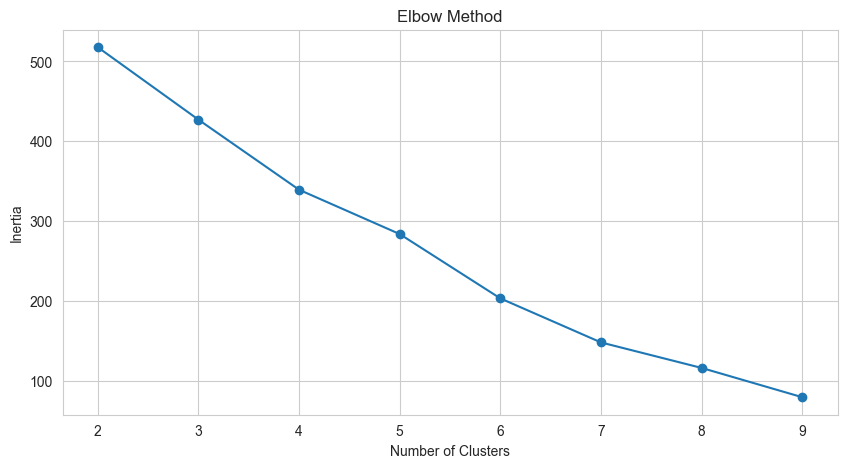

In [28]:
plt.figure(figsize=(10,5))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

cluster_data["kmeans_cluster"] = (
    kmeans.fit_predict(X_scaled)
)

In [30]:
cluster_data.head()

,avg_opm,avg_roe,avg_growth_3y,avg_debt_to_equity,avg_cash_conversion,avg_dividend,kmeans_cluster
company_id,,,,,,,
ABB,17.873472,9315.734266,54.213467,0.019963,2.822420,49.416667,0
ADANIENSOL,46.294412,600.414045,2706.236101,3.003669,3.976267,0.000000,2
ADANIENT,9.180307,20320.850884,30.179624,1.777247,4.059843,7.666667,4
ADANIGREEN,69.613593,178.985514,177.786060,8.291258,-1.174597,0.000000,1
ADANIPORTS,60.670344,6375.659199,99.577551,1.275917,1.441998,13.000000,1


In [31]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=3
)

cluster_data["dbscan_cluster"] = (
    dbscan.fit_predict(X_scaled)
)

In [32]:
cluster_data.head()

,avg_opm,avg_roe,avg_growth_3y,avg_debt_to_equity,avg_cash_conversion,avg_dividend,kmeans_cluster,dbscan_cluster
company_id,,,,,,,,
ABB,17.873472,9315.734266,54.213467,0.019963,2.822420,49.416667,0,0
ADANIENSOL,46.294412,600.414045,2706.236101,3.003669,3.976267,0.000000,2,-1
ADANIENT,9.180307,20320.850884,30.179624,1.777247,4.059843,7.666667,4,0
ADANIGREEN,69.613593,178.985514,177.786060,8.291258,-1.174597,0.000000,1,0
ADANIPORTS,60.670344,6375.659199,99.577551,1.275917,1.441998,13.000000,1,0


In [33]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

In [34]:
cluster_data["pca1"] = pca_result[:,0]

cluster_data["pca2"] = pca_result[:,1]

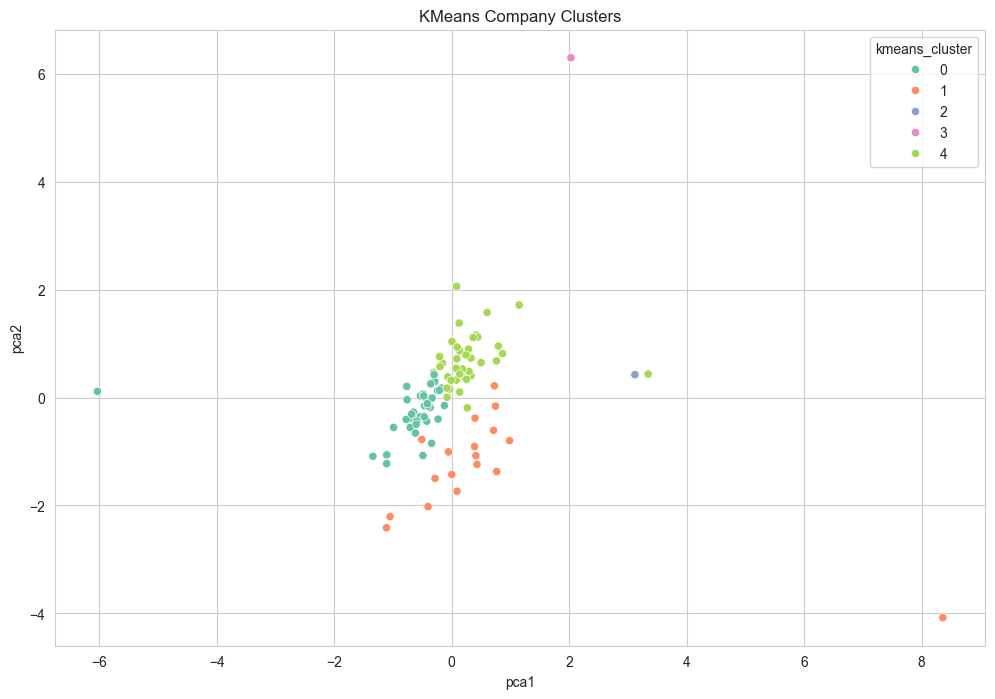

In [35]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=cluster_data,
    x="pca1",
    y="pca2",
    hue="kmeans_cluster",
    palette="Set2"
)

plt.title("KMeans Company Clusters")

plt.show()

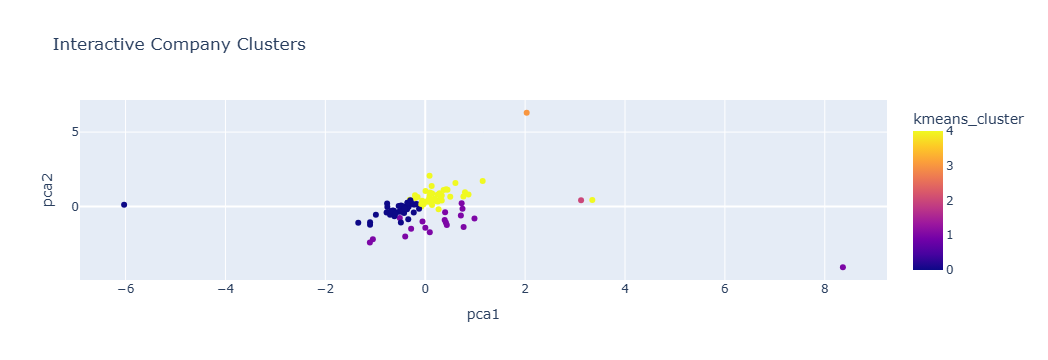

In [36]:
fig = px.scatter(
    cluster_data.reset_index(),
    x="pca1",
    y="pca2",
    color="kmeans_cluster",
    hover_name="company_id",
    title="Interactive Company Clusters"
)

fig.show()

In [37]:
cluster_summary = (
    cluster_data.groupby("kmeans_cluster")
    .mean()
)

In [38]:
cluster_summary

,avg_opm,avg_roe,avg_growth_3y,avg_debt_to_equity,avg_cash_conversion,avg_dividend,dbscan_cluster,pca1,pca2
kmeans_cluster,,,,,,,,,
0,19.431286,9312.182018,51.498486,0.468663,-0.218166,43.309608,-0.024390,-0.670335,-0.252896
1,84.398870,78169.716910,78.530495,2.254730,2.019473,28.387205,-0.055556,0.590513,-1.305880
2,46.294412,600.414045,2706.236101,3.003669,3.976267,0.000000,-1.000000,3.120203,0.423910
3,1.638868,1667.782028,16.174846,83.548647,8.905728,7.833333,-1.000000,2.031508,6.298112
4,19.018310,14342.351827,66.805216,3.476247,1.896340,7.738820,-0.050000,0.292570,0.678814


In [39]:
cluster_labels = {
    0: "High Growth Low Debt",
    1: "Stable Dividend",
    2: "Weak Cash Conversion",
    3: "Aggressive Growth",
    4: "Defensive Mature"
}

In [40]:
cluster_data["cluster_label"] = (
    cluster_data["kmeans_cluster"]
    .map(cluster_labels)
)

In [41]:
cluster_data.head()

,avg_opm,avg_roe,avg_growth_3y,avg_debt_to_equity,avg_cash_conversion,avg_dividend,kmeans_cluster,dbscan_cluster,pca1,pca2,cluster_label
company_id,,,,,,,,,,,
ABB,17.873472,9315.734266,54.213467,0.019963,2.822420,49.416667,0,0,-0.609661,-0.402380,High Growth Low Debt
ADANIENSOL,46.294412,600.414045,2706.236101,3.003669,3.976267,0.000000,2,-1,3.120203,0.423910,Weak Cash Conversion
ADANIENT,9.180307,20320.850884,30.179624,1.777247,4.059843,7.666667,4,0,0.330731,0.731191,Defensive Mature
ADANIGREEN,69.613593,178.985514,177.786060,8.291258,-1.174597,0.000000,1,0,0.728929,0.216837,Stable Dividend
ADANIPORTS,60.670344,6375.659199,99.577551,1.275917,1.441998,13.000000,1,0,0.398097,-0.382504,Stable Dividend


In [43]:
analysis.columns

Index(['id', 'company_id', 'compounded_sales_growth',
       'compounded_profit_growth', 'stock_price_cagr', 'roe'],
      dtype='object')

In [44]:
sector_map = pd.DataFrame({
    "company_id": [
        "TCS",
        "INFY",
        "WIPRO",
        "HDFCBANK",
        "ICICIBANK",
        "RELIANCE"
    ],
    "sector": [
        "IT",
        "IT",
        "IT",
        "BANKING",
        "BANKING",
        "ENERGY"
    ]
})

In [45]:
cluster_data = cluster_data.merge(
    sector_map,
    on="company_id",
    how="left"
)

In [46]:
pd.crosstab(
    cluster_data["sector"],
    cluster_data["kmeans_cluster"]
)

kmeans_cluster,0,1,4
sector,,,
BANKING,0,1,1
ENERGY,0,0,1
IT,2,0,1


In [47]:
cluster_data.to_csv(
    "exports/company_clusters.csv",
    index=False
)

In [48]:
import os

os.listdir("exports")

['anomaly_flags.csv',
 'clean_analysis.csv',
 'clean_balance_sheet.csv',
 'clean_cash_flow.csv',
 'clean_profit_loss.csv',
 'company_clusters.csv',
 'company_health_scores.csv',
 'sales_growth.csv']